# ¿A quién llega el dinero? Concentración de las transferencias del Estado a las municipalidades del Perú, 2024

**Hito 2: Preparación de datos y primera matriz analítica**

### Problema
En 2024 el Estado transfirió a las 1,891 municipalidades del país más de S/ 27 mil millones por distintos
rubros (canon, FONCOMUN, impuestos municipales, entre otros), cada uno con reglas de reparto propias.
Los montos los publica el MEF y las características de las municipalidades el INEI, en sistemas separados.
Por eso **no existe una vista por municipalidad que muestre qué tan concentrado está ese reparto ni qué
municipalidades reciben montos muy por encima o muy por debajo del resto**.

**Pregunta:** ¿qué tan concentradas están las transferencias 2024 entre las municipalidades y cuáles se ubican en los extremos?

| | |
|---|---|
| **Usuario** | MEF – Dirección General del Tesoro Público; Contraloría General de la República; gerencias municipales |
| **Decisión que habilita** | Priorizar qué municipalidades revisar (montos atípicamente altos o bajos) |
| **Objetivo** | Construir una base integrada y una matriz analítica por municipalidad que permita medir la concentración e identificar casos atípicos |
| **Fuente A** | MEF — Transferencias de fondos y asignaciones financieras, 2024 |
| **Fuente B** | INEI — Registro Nacional de Municipalidades (RENAMU) 2025 |
| **Clave** | UBIGEO de 6 dígitos |
| **Unidad de análisis** | Una municipalidad (un distrito), ejercicio 2024 |

Flujo: descarga → inspección → diagnóstico → validación de clave → limpieza → integración (1:1) →
atípicos → EDA (3 gráficos) → transformaciones → matriz analítica.

> Ejecutar en Google Colab: `Entorno de ejecución` > `Ejecutar todas`.

## 0. Configuración

In [1]:
import os, zipfile, glob, time, warnings, unicodedata
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
AZUL, ORO, GRIS = "#1F3864", "#BF8F00", "#9AA0A6"

ANIO = 2024                 # ejercicio a analizar
GUARDAR_EN_DRIVE = False    # True: las descargas sobreviven a una desconexion de Colab

CARPETA = "datos"
if GUARDAR_EN_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        CARPETA = "/content/drive/MyDrive/hito2_datos"
    except Exception as e:
        print("No se pudo montar Drive, se usara almacenamiento temporal:", e)

for d in [CARPETA, "graficos", "salidas"]:
    os.makedirs(d, exist_ok=True)

def guardar(fig, nombre):
    """Guarda cada grafico con un nombre fijo (no depende del orden de ejecucion)."""
    ruta = f"graficos/{nombre}.png"
    fig.savefig(ruta, dpi=150, bbox_inches="tight")
    print(f"[guardado: {ruta}]")

print(f"Ejercicio: {ANIO} | Carpeta de datos: {CARPETA} | pandas {pd.__version__}")

Ejercicio: 2024 | Carpeta de datos: datos | pandas 2.2.3


## 1. Descarga de las fuentes

| Fuente | Entidad | Archivo | Enlace |
|---|---|---|---|
| A | MEF | `2024-Transferencias.csv` | `https://fs.datosabiertos.mef.gob.pe/datastorefiles/2024-Transferencias.csv` |
| A (diccionario) | MEF | `Transferencias_Diccionario.csv` | `https://fs.datosabiertos.mef.gob.pe/datastorefiles/Transferencias_Diccionario.csv` |
| B | INEI | `984-Modulo1963.zip` | `https://proyectos.inei.gob.pe/iinei/srienaho/descarga/CSV/984-Modulo1963.zip` |

Ruta manual si el enlace cambiara: Plataforma Nacional de Datos Abiertos → *"Transferencias de fondos y asignaciones
financieras"* (MEF) y *"RENAMU 2025"* (INEI). Si un archivo ya está en la carpeta, no se vuelve a descargar.

In [2]:
BASE_MEF     = "https://fs.datosabiertos.mef.gob.pe/datastorefiles/"
URL_MEF      = f"{BASE_MEF}{ANIO}-Transferencias.csv"
URL_MEF_DIC  = f"{BASE_MEF}Transferencias_Diccionario.csv"
URL_RENAMU   = "https://proyectos.inei.gob.pe/iinei/srienaho/descarga/CSV/984-Modulo1963.zip"

RUTA_MEF     = f"{CARPETA}/{ANIO}-Transferencias.csv"
RUTA_MEF_DIC = f"{CARPETA}/Transferencias_Diccionario.csv"
RUTA_RENAMU  = f"{CARPETA}/renamu2025.zip"


def descargar(url, destino, avisar_cada_mb=20):
    """Descarga mostrando progreso. Si el archivo ya existe, no lo repite."""
    if os.path.exists(destino) and os.path.getsize(destino) > 0:
        print(f"Ya existe: {os.path.basename(destino)} ({os.path.getsize(destino)/1024**2:,.1f} MB)")
        return
    with requests.get(url, stream=True, timeout=(30, 180), verify=False) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        print(f"Descargando {os.path.basename(destino)} — "
              + (f"{total/1024**2:,.0f} MB" if total else "tamano desconocido"))
        bajado, ultimo, t0 = 0, 0, time.time()
        with open(destino, "wb") as f:
            for trozo in r.iter_content(chunk_size=1024 * 1024):
                if not trozo:
                    continue
                f.write(trozo)
                bajado += len(trozo)
                if bajado - ultimo >= avisar_cada_mb * 1024**2:
                    ultimo = bajado
                    print(f"   {bajado/1024**2:7,.0f} MB   {time.time()-t0:5.0f} s")
    print(f"Listo: {os.path.basename(destino)} ({os.path.getsize(destino)/1024**2:,.1f} MB)")

descargar(URL_MEF_DIC, RUTA_MEF_DIC)
descargar(URL_RENAMU,  RUTA_RENAMU)
descargar(URL_MEF,     RUTA_MEF)

Descargando Transferencias_Diccionario.csv — 0 MB
Listo: Transferencias_Diccionario.csv (0.0 MB)
Descargando renamu2025.zip — 2 MB
Listo: renamu2025.zip (2.1 MB)
Descargando 2024-Transferencias.csv — 107 MB
        20 MB       2 s
        40 MB       3 s
        60 MB       4 s
        80 MB       5 s
       100 MB       6 s
Listo: 2024-Transferencias.csv (107.0 MB)


## 2. Lectura: detección de separador y codificación

Los CSV de entidades públicas peruanas suelen venir en `latin-1` y con `;`. Se prueba en lugar de asumir.

In [3]:
def detectar_formato(ruta, nfilas=5):
    """Prueba combinaciones de codificacion y separador y devuelve la que funciona."""
    for enc in ["utf-8", "latin-1", "cp1252"]:
        for sep in [",", ";", "|", "\t"]:
            try:
                m = pd.read_csv(ruta, sep=sep, encoding=enc, nrows=nfilas, dtype=str, engine="python")
                if m.shape[1] > 1:
                    return sep, enc, m
            except Exception:
                continue
    raise ValueError(f"No se pudo leer {ruta}")

SEP_MEF, ENC_MEF, muestra_mef = detectar_formato(RUTA_MEF)
print(f"Fuente A -> separador '{SEP_MEF}' | codificacion '{ENC_MEF}' | {muestra_mef.shape[1]} columnas")
muestra_mef.head(3)

Fuente A -> separador ',' | codificacion 'utf-8' | 26 columnas


,ANO_PRC,MES_PRC,MES_PRC_NOMBRE,GRUPO_TRANSFERENCIA,GRUPO_TRANSFERENCIA_NOMBRE,TIPO_ENTIDAD,TIPO_ENTIDAD_NOMBRE,PLIEGO,PLIEGO_NOMBRE,SEC_EJEC,EJECUTORA_NOMBRE,DEPARTAMENTO_EJECUTORA,DEPARTAMENTO_EJECUTORA_NOMBRE,PROVINCIA_EJECUTORA,PROVINCIA_EJECUTORA_NOMBRE,DISTRITO_EJECUTORA,DISTRITO_EJECUTORA_NOMBRE,RUBRO,RUBRO_NOMBRE,FUENTE,FUENTE_NOMBRE,RECURSO,RECURSO_NOMBRE,ORIGEN_OPERACION_NOMBRE,MONTO_AUTORIZADO,MONTO_ACREDITADO
0,2024,6,JUNIO,4,INTERESES,M,GOBIERNO LOCAL,,,301086,MUNICIPALIDAD PROVINCIAL DE JUNIN,12,JUNIN,05,JUNIN,01,JUNIN,08,IMPUESTOS MUNICIPALES,5,RECURSOS DETERMINADOS,729,IMPUESTOS MUNICIPALES,INTERESES DE ASIGNACION,313.3,313.3
1,2024,4,ABRIL,1,RECURSOS AUTORIZADOS,M,GOBIERNO LOCAL,,,301086,MUNICIPALIDAD PROVINCIAL DE JUNIN,12,JUNIN,05,JUNIN,01,JUNIN,09,RECURSOS DIRECTAMENTE RECAUDADOS,2,RECURSOS DIRECTAMENTE RECAUDADOS,516,RECURSOS DIRECTAMENTE RECAUDADOS,ASIGNACION NORMAL,100000,100000
2,2024,2,FEBRERO,4,INTERESES,M,GOBIERNO LOCAL,,,301086,MUNICIPALIDAD PROVINCIAL DE JUNIN,12,JUNIN,05,JUNIN,01,JUNIN,07,FONDO DE COMPENSACION MUNICIPAL,5,RECURSOS DETERMINADOS,547,SUB CUENTA - SALDOS DE TRANSFERENCIAS - FONCOMUN,INTERESES DE ASIGNACION,0.22,0.22


## 3. Fuente A (MEF): inspección, filtro y agregación

**Qué representa cada fila del archivo original:** una transferencia a una *unidad ejecutora × mes × rubro × concepto*.
Nuestra unidad es la municipalidad, así que habrá que **agregar** (relación N:1 con el distrito).

In [4]:
sep_d, enc_d, _ = detectar_formato(RUTA_MEF_DIC)
diccionario_mef = pd.read_csv(RUTA_MEF_DIC, sep=sep_d, encoding=enc_d, dtype=str)
print("Diccionario oficial del MEF:", diccionario_mef.shape)
diccionario_mef

Diccionario oficial del MEF: (26, 3)


,COLUMNA,TIPO_DATO,DESCRIPCION
0,ANO_PRC,Numérico,Año del proceso de la operación
1,MES_PRC,Numérico,Mes del proceso de la operación
2,MES_PRC_NOMBRE,Carácter,Nombre del mes del proceso de la operación
3,GRUPO_TRANSFERENCIA,Numérico,Código del grupo de Transferencia
4,GRUPO_TRANSFERENCIA_NOMBRE,Carácter,Nombre del grupo de Transferencia
5,TIPO_ENTIDAD,Carácter,Código de la Entidad SIAF
6,TIPO_ENTIDAD_NOMBRE,Carácter,Nombre de la Entidad SIAF
7,PLIEGO,Numérico,Código del Pliego
8,PLIEGO_NOMBRE,Carácter,Nombre del Pliego
9,SEC_EJEC,Numérico,Código de la Unidad Ejecutora


In [5]:
columnas_mef = list(muestra_mef.columns)
print(f"El archivo trae {len(columnas_mef)} columnas.")

DESEADAS = [
    "ANO_PRC", "MES_PRC", "TIPO_ENTIDAD_NOMBRE", "EJECUTORA_NOMBRE",
    "DEPARTAMENTO_EJECUTORA", "DEPARTAMENTO_EJECUTORA_NOMBRE",
    "PROVINCIA_EJECUTORA", "DISTRITO_EJECUTORA",
    "RUBRO_NOMBRE", "MONTO_AUTORIZADO", "MONTO_ACREDITADO",
]
USAR   = [x for x in DESEADAS if x in columnas_mef]
FALTAN = [x for x in DESEADAS if x not in columnas_mef]
print("Se usaran", len(USAR), "columnas", "| faltan:", FALTAN if FALTAN else "ninguna")

IMPRESCINDIBLES = ["TIPO_ENTIDAD_NOMBRE", "DEPARTAMENTO_EJECUTORA", "PROVINCIA_EJECUTORA",
                   "DISTRITO_EJECUTORA", "RUBRO_NOMBRE", "MONTO_AUTORIZADO", "MONTO_ACREDITADO"]
assert all(x in USAR for x in IMPRESCINDIBLES), "Faltan columnas imprescindibles"
print("Columnas imprescindibles: OK")

El archivo trae 26 columnas.
Se usaran 11 columnas | faltan: ninguna
Columnas imprescindibles: OK


### 3.1 Categorías reales del tipo de entidad (archivo completo)

Se lee **solo** la columna de tipo de entidad del archivo completo (es liviana) para ver todas sus categorías,
en vez de suponerlas a partir de una muestra.

In [6]:
tipos_entidad = pd.read_csv(RUTA_MEF, sep=SEP_MEF, encoding=ENC_MEF,
                            usecols=["TIPO_ENTIDAD_NOMBRE"], dtype=str)["TIPO_ENTIDAD_NOMBRE"]
print(tipos_entidad.value_counts(dropna=False))

# Se conservan solo los gobiernos locales (municipalidades).
# Las mancomunidades se EXCLUYEN: agrupan a varias municipalidades y no corresponden a un solo distrito.
LOCALES = [e for e in tipos_entidad.dropna().unique()
           if "LOCAL" in e.upper() and "MANCOMUN" not in e.upper()]
EXCLUIDAS = [e for e in tipos_entidad.dropna().unique() if e not in LOCALES]
print("\nSe conservan:", LOCALES)
print("Se excluyen :", EXCLUIDAS)
assert LOCALES, "Ninguna categoria corresponde a gobierno local; revisar el filtro."

TIPO_ENTIDAD_NOMBRE
GOBIERNO LOCAL       306872
GOBIERNO REGIONAL     27497
GOBIERNO NACIONAL      6668
EPS                     613
MANCOMUNIDADES           16
Name: count, dtype: int64

Se conservan: ['GOBIERNO LOCAL']
Se excluyen : ['MANCOMUNIDADES', 'GOBIERNO NACIONAL', 'GOBIERNO REGIONAL', 'EPS']


### 3.2 Lectura por bloques y agregación a nivel de distrito

- Códigos geográficos como **texto** (`dtype=str`): si se leyeran como número, Amazonas `01` pasaría a `1` y el cruce fallaría.
- Montos con `errors="coerce"`: un valor corrupto se vuelve nulo y se **cuenta**.
- Se registran los montos negativos del **detalle** (antes de sumar), para saber si existen rectificaciones.
- Además del total por distrito, se guarda el monto por **distrito × rubro**, para medir cuánto depende cada municipalidad del canon.

In [7]:
MONTOS = ["MONTO_AUTORIZADO", "MONTO_ACREDITADO"]
tipos = {c: str for c in USAR if c not in MONTOS}

acumulado, por_rubro_dist, catalogo = [], [], []
filas_total = filas_local = 0
no_numericos = {m: 0 for m in MONTOS}
negativos_detalle = {m: 0 for m in MONTOS}

lector = pd.read_csv(RUTA_MEF, sep=SEP_MEF, encoding=ENC_MEF, usecols=USAR,
                     dtype=tipos, chunksize=500_000, low_memory=False)

for bloque in lector:
    filas_total += len(bloque)
    bloque = bloque[bloque["TIPO_ENTIDAD_NOMBRE"].isin(LOCALES)].copy()
    filas_local += len(bloque)
    if bloque.empty:
        continue

    for m in MONTOS:
        antes = bloque[m].isna().sum()
        bloque[m] = pd.to_numeric(bloque[m], errors="coerce")
        no_numericos[m] += int(bloque[m].isna().sum() - antes)
        negativos_detalle[m] += int((bloque[m] < 0).sum())

    bloque["UBIGEO"] = (bloque["DEPARTAMENTO_EJECUTORA"].str.strip().str.zfill(2)
                        + bloque["PROVINCIA_EJECUTORA"].str.strip().str.zfill(2)
                        + bloque["DISTRITO_EJECUTORA"].str.strip().str.zfill(2))

    acumulado.append(bloque.groupby("UBIGEO", as_index=False)[MONTOS].sum())
    por_rubro_dist.append(bloque.groupby(["UBIGEO", "RUBRO_NOMBRE"], as_index=False)["MONTO_ACREDITADO"].sum())
    catalogo.append(bloque[["UBIGEO", "EJECUTORA_NOMBRE", "DEPARTAMENTO_EJECUTORA_NOMBRE"]]
                    .dropna().drop_duplicates("UBIGEO"))

print(f"Filas del archivo           : {filas_total:,}")
print(f"Filas de gobiernos locales  : {filas_local:,}  ({filas_total - filas_local:,} excluidas)")
print(f"Montos no numericos         : {no_numericos}")
print(f"Montos negativos en detalle : {negativos_detalle}")

Filas del archivo           : 341,666
Filas de gobiernos locales  : 306,872  (34,794 excluidas)
Montos no numericos         : {'MONTO_AUTORIZADO': 0, 'MONTO_ACREDITADO': 0}
Montos negativos en detalle : {'MONTO_AUTORIZADO': 198, 'MONTO_ACREDITADO': 198}


In [10]:
#Consolidar: una fila por UBIGEO (paso de N filas de detalle a 1 fila por distrito)
mef = (pd.concat(acumulado, ignore_index=True)
         .groupby("UBIGEO", as_index=False)[MONTOS].sum())

nombres = pd.concat(catalogo, ignore_index=True).drop_duplicates("UBIGEO")
mef = mef.merge(nombres, on="UBIGEO", how="left").rename(columns={
    "EJECUTORA_NOMBRE": "MUNICIPALIDAD", "DEPARTAMENTO_EJECUTORA_NOMBRE": "DEPARTAMENTO_MEF"})

#Monto por distrito x rubro -> participacion del canon y del FONCOMUN en lo que recibe cada distrito
rubro_dist = (pd.concat(por_rubro_dist, ignore_index=True)
                .groupby(["UBIGEO", "RUBRO_NOMBRE"], as_index=False)["MONTO_ACREDITADO"].sum())
pivote = rubro_dist.pivot_table(index="UBIGEO", columns="RUBRO_NOMBRE",
                                values="MONTO_ACREDITADO", aggfunc="sum", fill_value=0)
col_canon = [c for c in pivote.columns if "CANON" in c.upper()]
col_fonc  = [c for c in pivote.columns if "COMPENSACION MUNICIPAL" in c.upper()]
print("Rubro canon  :", col_canon)
print("Rubro FONCOMUN:", col_fonc)

total_dist = pivote.sum(axis=1)
partes = pd.DataFrame({
    "UBIGEO": pivote.index,
    "PCT_CANON":    np.where(total_dist > 0, 100 * pivote[col_canon].sum(axis=1) / total_dist, np.nan),
    "PCT_FONCOMUN": np.where(total_dist > 0, 100 * pivote[col_fonc].sum(axis=1) / total_dist, np.nan),
})
mef = mef.merge(partes, on="UBIGEO", how="left")

#Totales nacionales por rubro (para el grafico 2)
rubros_nac = (rubro_dist.groupby("RUBRO_NOMBRE")["MONTO_ACREDITADO"].sum()
                        .sort_values(ascending=False))

print("\nFuente A agregada a nivel distrito:", mef.shape)
mef.head()

Rubro canon  : ['CANON Y SOBRECANON, REGALIAS, RENTA DE ADUANAS Y PARTICIPACIONES']
Rubro FONCOMUN: ['FONDO DE COMPENSACION MUNICIPAL']

Fuente A agregada a nivel distrito: (1891, 7)


,UBIGEO,MONTO_AUTORIZADO,MONTO_ACREDITADO,MUNICIPALIDAD,DEPARTAMENTO_MEF,PCT_CANON,PCT_FONCOMUN
0,010101,20418557.60,20396056.85,MUNICIPALIDAD PROVINCIAL DE CHACHAPOYAS,AMAZONAS,0.869058,35.933463
1,010102,599031.30,599375.20,MUNICIPALIDAD DISTRITAL DE ASUNCION,AMAZONAS,5.687324,93.249772
2,010103,604515.32,604706.50,MUNICIPALIDAD DISTRITAL DE BALSAS,AMAZONAS,2.424484,92.365946
3,010104,735512.76,735704.56,MUNICIPALIDAD DISTRITAL DE CHETO,AMAZONAS,2.825072,75.990665
4,010105,641171.34,641793.06,MUNICIPALIDAD DISTRITAL DE CHILIQUIN,AMAZONAS,4.093647,87.161276


## 4. Fuente B (INEI: RENAMU 2025)

**Qué representa cada fila:** una municipalidad (provincial, distrital o de centro poblado).
El ZIP puede traer varios módulos; se usa el que tenga columna `UBIGEO` y más variables.

In [11]:
with zipfile.ZipFile(RUTA_RENAMU) as z:
    z.extractall(f"{CARPETA}/renamu")

archivos = [p for p in glob.glob(f"{CARPETA}/renamu/**/*", recursive=True)
            if p.lower().endswith((".csv", ".txt"))]
candidatos = []
for p in archivos:
    try:
        sep, enc, m = detectar_formato(p)
        if any(c.strip().lower() == "ubigeo" for c in m.columns):
            candidatos.append((p, sep, enc, m.shape[1]))
        print(f"{os.path.basename(p)}  sep='{sep}' enc='{enc}' cols={m.shape[1]}")
    except Exception as e:
        print(f"XX {os.path.basename(p)}: {e}")

assert candidatos, "Ningun archivo del ZIP tiene columna UBIGEO."
RUTA_B, SEP_B, ENC_B, _ = max(candidatos, key=lambda t: t[3])

renamu = pd.read_csv(RUTA_B, sep=SEP_B, encoding=ENC_B, dtype=str, low_memory=False)
renamu.columns = [c.strip().lower() for c in renamu.columns]
col_tipo = next((c for c in renamu.columns if c.startswith("tipomuni")), None)
ID_RENAMU = [c for c in ["ubigeo", "departamento", "provincia", "distrito", col_tipo] if c]
print(f"\nModulo elegido: {os.path.basename(RUTA_B)} | {renamu.shape[0]:,} filas x {renamu.shape[1]:,} columnas")
print("Se usan solo las columnas de identificacion:", ID_RENAMU)

Base-Datos_2025_f_.csv  sep=';' enc='utf-8' cols=1388

Modulo elegido: Base-Datos_2025_f_.csv | 1,891 filas x 1,388 columnas
Se usan solo las columnas de identificacion: ['ubigeo', 'departamento', 'provincia', 'distrito', 'tipomuni']


## 5. Diagnóstico de calidad: tipos, faltantes y valores distintos

In [12]:
def tabla_resumen(df, nombre):
    filas = []
    for col in df.columns:
        s = df[col]
        filas.append({"columna": col, "tipo": str(s.dtype),
                      "faltantes": int(s.isna().sum()),
                      "%_faltantes": round(100 * s.isna().mean(), 2),
                      "distintos": int(s.nunique(dropna=True)),
                      "ejemplos": " | ".join(map(str, s.dropna().unique()[:3]))})
    print(f"=== {nombre} — {df.shape[0]:,} filas x {df.shape[1]} columnas ===")
    return pd.DataFrame(filas)

tabla_resumen(mef, "FUENTE A — MEF agregada por distrito")

=== FUENTE A — MEF agregada por distrito — 1,891 filas x 7 columnas ===


,columna,tipo,faltantes,%_faltantes,distintos,ejemplos
0,UBIGEO,object,0,0.0,1891,010101 | 010102 | 010103
1,MONTO_AUTORIZADO,float64,0,0.0,1891,20418557.6 | 599031.3 | 604515.32
2,MONTO_ACREDITADO,float64,0,0.0,1891,20396056.85 | 599375.2 | 604706.5
3,MUNICIPALIDAD,object,0,0.0,1769,MUNICIPALIDAD PROVINCIAL DE CHACHAPOYAS | MUNI...
4,DEPARTAMENTO_MEF,object,0,0.0,25,AMAZONAS | ANCASH | APURIMAC
5,PCT_CANON,float64,0,0.0,1891,0.8690577855493671 | 5.687324066794889 | 2.424...
6,PCT_FONCOMUN,float64,0,0.0,1891,35.93346274674656 | 93.24977242969011 | 92.365...


In [14]:
display(tabla_resumen(renamu[ID_RENAMU], "FUENTE B — RENAMU, columnas usadas"))

#Las demas columnas de RENAMU no se usan en este hito; se reporta su nivel general de faltantes
resto = renamu.drop(columns=ID_RENAMU)
print(f"Columnas de RENAMU no usadas: {resto.shape[1]:,} | "
      f"faltantes promedio en ellas: {100*resto.isna().mean().mean():.1f}%")

=== FUENTE B — RENAMU, columnas usadas — 1,891 filas x 5 columnas ===


,columna,tipo,faltantes,%_faltantes,distintos,ejemplos
0,ubigeo,object,0,0.0,1891,010101 | 010102 | 010103
1,departamento,object,0,0.0,25,AMAZONAS | ANCASH | APURIMAC
2,provincia,object,0,0.0,196,CHACHAPOYAS | BAGUA | BONGARA
3,distrito,object,0,0.0,1735,CHACHAPOYAS | ASUNCION | BALSAS
4,tipomuni,object,0,0.0,2,1 | 2


Columnas de RENAMU no usadas: 1,383 | faltantes promedio en ellas: 5.8%


## 6. Validación de la clave UBIGEO

No se da por buena la clave porque se llame igual en ambas tablas: se revisa longitud, formato, unicidad y solapamiento.

In [15]:
def validar_clave(serie, nombre):
    print(f"{nombre}: registros={len(serie):,} | distintos={serie.nunique():,} | "
          f"duplicados={int(serie.duplicated().sum())} | "
          f"6 digitos={bool(serie.str.fullmatch(r'\d{6}').all())}")

mef["UBIGEO"] = mef["UBIGEO"].astype(str).str.strip().str.zfill(6)
renamu["ubigeo"] = renamu["ubigeo"].astype(str).str.strip().str.zfill(6)
validar_clave(mef["UBIGEO"], "Fuente A (MEF)   ")
validar_clave(renamu["ubigeo"], "Fuente B (RENAMU)")

if col_tipo:
    print("\nTipo de municipalidad en RENAMU (1=provincial, 2=distrital, 3=centro poblado):")
    print(renamu[col_tipo].value_counts(dropna=False).sort_index())

set_a, set_b = set(mef["UBIGEO"]), set(renamu["ubigeo"])
print(f"\nSolo en MEF: {len(set_a - set_b)} | Solo en RENAMU: {len(set_b - set_a)} | En ambas: {len(set_a & set_b)}")

Fuente A (MEF)   : registros=1,891 | distintos=1,891 | duplicados=0 | 6 digitos=True
Fuente B (RENAMU): registros=1,891 | distintos=1,891 | duplicados=0 | 6 digitos=True

Tipo de municipalidad en RENAMU (1=provincial, 2=distrital, 3=centro poblado):
tipomuni
1     196
2    1695
Name: count, dtype: int64

Solo en MEF: 0 | Solo en RENAMU: 0 | En ambas: 1891


## 7. Limpieza — decisiones justificadas

Cada decisión se aplica **después** del diagnóstico. Algunas son controles preventivos:
se programan igual, porque si el archivo de otro año trae el problema, el cuaderno lo trata en vez de fallar en silencio.

In [16]:
#DECISION 1: excluir municipalidades de centro poblado (tipomuni = 3).
#Comparten el UBIGEO de su distrito (romperian la unicidad de la clave) y no reciben transferencias propias.
antes = len(renamu)
renamu_l = renamu[renamu[col_tipo].astype(str).str.strip() != "3"].copy() if col_tipo else renamu.copy()
print(f"DECISION 1 — centros poblados eliminados: {antes - len(renamu_l)}")

#DECISION 2: si quedaran UBIGEO repetidos, conservar el primero y reportarlo.
rep = int(renamu_l["ubigeo"].duplicated().sum())
renamu_l = renamu_l.drop_duplicates("ubigeo", keep="first")
print(f"DECISION 2 — duplicados de UBIGEO eliminados: {rep} | clave unica: {renamu_l['ubigeo'].is_unique}")

#DECISION 3: los montos negativos NO se eliminan (son rectificaciones/devoluciones de la DGTP).
print("\nDECISION 3 — montos negativos")
for m in MONTOS:
    print(f"  {m:<17} detalle: {negativos_detalle[m]:>5} | agregado por distrito: {int((mef[m] < 0).sum()):>3}"
          f" | igual a cero: {int((mef[m] == 0).sum()):>3}")
print("  Se conservan: forman parte del monto neto que recibe cada municipalidad.")

#DECISION 4: indicador de acreditacion, protegido contra division por cero.
mef["ACREDITACION_PCT"] = np.where(mef["MONTO_AUTORIZADO"] > 0,
                                   100 * mef["MONTO_ACREDITADO"] / mef["MONTO_AUTORIZADO"], np.nan)
a = mef["ACREDITACION_PCT"]
print("\nDECISION 4 — ACREDITACION_PCT")
print(a.describe().round(2).to_string())
print(f"  < 99.99%: {int((a < 99.99).sum())} | entre 99.99% y 100.01%: {int(a.between(99.99, 100.01).sum())}"
      f" | > 100.01%: {int((a > 100.01).sum())} | fuera de 90–110%: {int(((a < 90) | (a > 110)).sum())}")

DECISION 1 — centros poblados eliminados: 0
DECISION 2 — duplicados de UBIGEO eliminados: 0 | clave unica: True

DECISION 3 — montos negativos
  MONTO_AUTORIZADO  detalle:   198 | agregado por distrito:   0 | igual a cero:   0
  MONTO_ACREDITADO  detalle:   198 | agregado por distrito:   0 | igual a cero:   0
  Se conservan: forman parte del monto neto que recibe cada municipalidad.

DECISION 4 — ACREDITACION_PCT
count    1891.00
mean      100.04
std         0.47
min        94.74
25%       100.04
50%       100.09
75%       100.17
max       101.73
  < 99.99%: 148 | entre 99.99% y 100.01%: 22 | > 100.01%: 1721 | fuera de 90–110%: 0


## 8. Integración

| | Antes de integrar | Después de integrar |
|---|---|---|
| Fuente A (MEF) | 1 fila = ejecutora × mes × rubro × concepto | agregada: 1 fila = 1 distrito |
| Fuente B (RENAMU) | 1 fila = 1 municipalidad (incluye centros poblados) | filtrada: 1 fila = 1 distrito |
| Base integrada | — | **1 fila = 1 municipalidad (distrito), 2024** |

**Cardinalidad esperada:** MEF detalle → distrito es **N:1** (se resuelve agregando); tras agregar, MEF ↔ RENAMU es **1:1**.
Se exige con `validate="one_to_one"`: si la clave no fuera única, pandas detiene la ejecución.

**Tipo de unión:** `LEFT JOIN` con RENAMU como tabla principal (marco completo de municipalidades): una municipalidad
sin transferencias se conservaría con monto nulo, porque eso sería un hallazgo, no un error.

In [17]:
base = renamu_l[ID_RENAMU].merge(mef, left_on="ubigeo", right_on="UBIGEO",
                                 how="left", validate="one_to_one", indicator=True)

print(f"Filas RENAMU limpio: {len(renamu_l):,} | filas base integrada: {len(base):,}")
assert len(base) == len(renamu_l), "El cruce multiplico filas"
print(base["_merge"].value_counts().to_string())
print(f"Tasa de cruce: {100*(base['_merge']=='both').mean():.1f}%")

sin_transf = base[base["_merge"] == "left_only"]
huerfanos  = sorted(set(mef["UBIGEO"]) - set(renamu_l["ubigeo"]))
print(f"\nMunicipalidades de RENAMU sin transferencias: {len(sin_transf)}")
print(f"UBIGEO del MEF sin contraparte en RENAMU    : {len(huerfanos)}")
if len(huerfanos):
    display(mef[mef["UBIGEO"].isin(huerfanos)][["UBIGEO", "MUNICIPALIDAD", "MONTO_ACREDITADO"]])

Filas RENAMU limpio: 1,891 | filas base integrada: 1,891
_merge
both          1891
left_only        0
right_only       0
Tasa de cruce: 100.0%

Municipalidades de RENAMU sin transferencias: 0
UBIGEO del MEF sin contraparte en RENAMU    : 0


In [18]:
#Control de consistencia: el departamento segun el MEF debe coincidir con el de RENAMU.
def normalizar(t):
    t = unicodedata.normalize("NFKD", str(t)).encode("ascii", "ignore").decode()
    return t.upper().strip()

difieren = base[base["departamento"].map(normalizar) != base["DEPARTAMENTO_MEF"].map(normalizar)]
print(f"Municipalidades con departamento distinto entre fuentes: {len(difieren)}")
if len(difieren):
    display(difieren[["ubigeo", "departamento", "DEPARTAMENTO_MEF", "MUNICIPALIDAD"]].head(10))
print("Decision: se usa el nombre de RENAMU (fuente oficial del marco); DEPARTAMENTO_MEF queda fuera de la matriz.")

Municipalidades con departamento distinto entre fuentes: 7


,ubigeo,departamento,DEPARTAMENTO_MEF,MUNICIPALIDAD
695,070101,CALLAO,PROVINCIA CONSTITUCIONAL DEL CALLAO,MUNICIPALIDAD PROVINCIAL DEL CALLAO
696,070102,CALLAO,PROVINCIA CONSTITUCIONAL DEL CALLAO,MUNICIPALIDAD DISTRITAL DE BELLAVISTA
697,070103,CALLAO,PROVINCIA CONSTITUCIONAL DEL CALLAO,MUNICIPALIDAD DISTRITAL DE CARMEN DE LA LEGUA ...
698,070104,CALLAO,PROVINCIA CONSTITUCIONAL DEL CALLAO,MUNICIPALIDAD DISTRITAL DE LA PERLA
699,070105,CALLAO,PROVINCIA CONSTITUCIONAL DEL CALLAO,MUNICIPALIDAD DISTRITAL DE LA PUNTA
700,070106,CALLAO,PROVINCIA CONSTITUCIONAL DEL CALLAO,MUNICIPALIDAD DISTRITAL DE VENTANILLA
701,070107,CALLAO,PROVINCIA CONSTITUCIONAL DEL CALLAO,MUNICIPALIDAD DISTRITAL DE MI PERU


Decision: se usa el nombre de RENAMU (fuente oficial del marco); DEPARTAMENTO_MEF queda fuera de la matriz.


## 9. Valores atípicos

El monto va de cientos de miles a cientos de millones de soles, así que la regla del rango intercuartílico (IQR)
se aplica sobre el **logaritmo** del monto: en escala original casi todo lo alto saldría "atípico".

**Decisión:** los atípicos **no se eliminan ni se recortan**. Identificar municipalidades en los extremos es
justamente el objetivo del proyecto; se **marcan** para el análisis siguiente.

In [19]:
base["LOG_MONTO"] = np.log10(base["MONTO_ACREDITADO"].where(base["MONTO_ACREDITADO"] > 0))

q1, q3 = base["LOG_MONTO"].quantile([0.25, 0.75])
iqr = q3 - q1
lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
base["ATIPICO"] = np.select([base["LOG_MONTO"] > lim_sup, base["LOG_MONTO"] < lim_inf],
                            ["alto", "bajo"], default="normal")

print(f"Limites (soles): inferior S/ {10**lim_inf:,.0f} | superior S/ {10**lim_sup:,.0f}")
print(base["ATIPICO"].value_counts().to_string())

cols_ver = ["distrito", "departamento", "MONTO_ACREDITADO", "PCT_CANON"]
print("\nAtipicos altos (mayor monto):")
display(base[base["ATIPICO"] == "alto"].nlargest(10, "MONTO_ACREDITADO")[cols_ver])
print("Atipicos bajos (menor monto):")
display(base[base["ATIPICO"] == "bajo"].nsmallest(10, "MONTO_ACREDITADO")[cols_ver])

Limites (soles): inferior S/ 95,309 | superior S/ 201,867,982
ATIPICO
normal    1879
alto        12

Atipicos altos (mayor monto):


,distrito,departamento,MONTO_ACREDITADO,PCT_CANON
1293,LIMA,LIMA,4.646221e+08,2.762055
695,CALLAO,CALLAO,4.247736e+08,21.398014
162,SAN MARCOS,ANCASH,3.580357e+08,97.661334
779,MEGANTONI,CUSCO,3.539501e+08,96.860990
1332,SANTIAGO DE SURCO,LIMA,3.417261e+08,0.189798
1324,SAN JUAN DE LURIGANCHO,LIMA,2.995778e+08,2.837056
1295,ATE,LIMA,2.541485e+08,1.647891
1314,MIRAFLORES,LIMA,2.529808e+08,0.075298
1171,TRUJILLO,LA LIBERTAD,2.470268e+08,4.453159
1323,SAN ISIDRO,LIMA,2.441115e+08,0.067339


Atipicos bajos (menor monto):


,distrito,departamento,MONTO_ACREDITADO,PCT_CANON


## 10. Análisis exploratorio (3 gráficos)

Se eligieron tres gráficos, uno por cada parte de la pregunta:

1. **¿Qué tan concentrado está el reparto?** → participación de cada 10% de municipalidades en el total.
2. **¿De dónde viene el dinero?** → peso de cada rubro.
3. **¿Quiénes están en el extremo superior?** → las 15 municipalidades que más reciben, distinguiendo si dependen del canon.

In [20]:
def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    return (2 * np.sum(np.arange(1, n + 1) * x)) / (n * x.sum()) - (n + 1) / n

m = base["MONTO_ACREDITADO"].dropna()
orden = m.sort_values()
total = m.sum()
CIFRAS = {
    "Municipalidades en la base": len(base),
    "Total acreditado (millones S/)": round(total / 1e6, 1),
    "Mediana por municipalidad (S/)": round(m.median()),
    "Promedio por municipalidad (S/)": round(m.mean()),
    "Indice de Gini": round(gini(m), 3),
    "% del total: 50% que menos recibe": round(100 * orden.iloc[: len(m) // 2].sum() / total, 1),
    "% del total: 10% que mas recibe": round(100 * orden.iloc[-len(m) // 10:].sum() / total, 1),
    "% del total: 1% que mas recibe": round(100 * orden.iloc[-len(m) // 100:].sum() / total, 1),
    "Atipicos altos": int((base["ATIPICO"] == "alto").sum()),
    "Atipicos bajos": int((base["ATIPICO"] == "bajo").sum()),
}
pd.Series(CIFRAS, name="valor").to_frame()

,valor
Municipalidades en la base,1.891000e+03
Total acreditado (millones S/),2.751050e+04
Mediana por municipalidad (S/),4.340954e+06
Promedio por municipalidad (S/),1.454811e+07
Indice de Gini,7.210000e-01
% del total: 50% que menos recibe,6.600000e+00
% del total: 10% que mas recibe,6.170000e+01
% del total: 1% que mas recibe,1.830000e+01
Atipicos altos,1.200000e+01
Atipicos bajos,0.000000e+00


[guardado: graficos/grafico_1_concentracion.png]


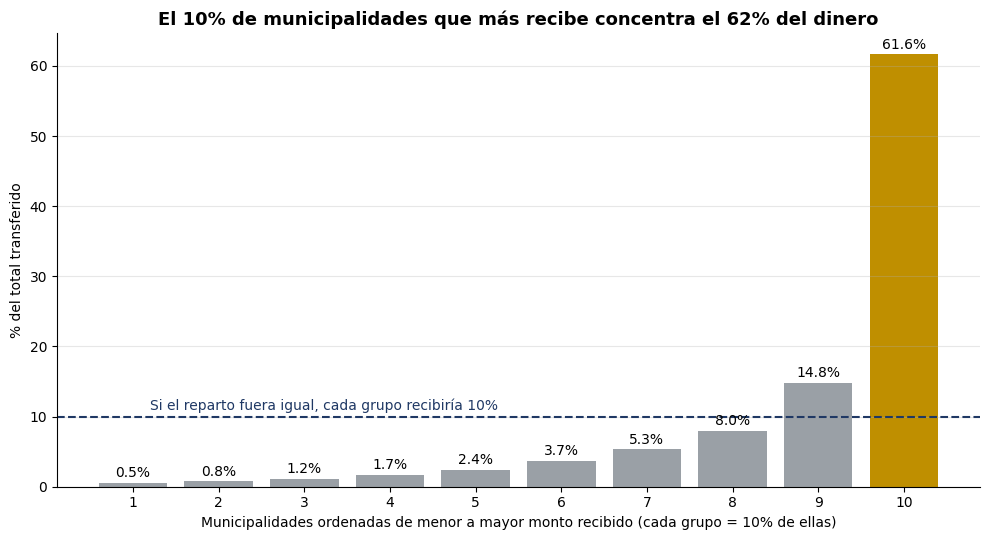

Lectura: el reparto esta concentrado (Gini = 0.721). Es una descripcion: parte de la diferencia responde a poblacion y a reglas legales como el canon.


In [21]:
#GRAFICO 1: cuanto del total recibe cada 10% de municipalidades
base["DECIL_MONTO"] = pd.qcut(base["MONTO_ACREDITADO"].rank(method="first"), 10, labels=range(1, 11)).astype("Int64")
part = base.groupby("DECIL_MONTO")["MONTO_ACREDITADO"].sum() / total * 100

fig, ax = plt.subplots(figsize=(10, 5.5))
colores = [GRIS] * 9 + [ORO]
barras = ax.bar(part.index.astype(str), part.values, color=colores)
ax.axhline(10, color=AZUL, ls="--", lw=1.5)
ax.text(0.2, 11, "Si el reparto fuera igual, cada grupo recibiría 10%", color=AZUL, fontsize=10)
for b, v in zip(barras, part.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.8, f"{v:.1f}%", ha="center", fontsize=10)
ax.set_title(f"El 10% de municipalidades que más recibe concentra el {part.iloc[-1]:.0f}% del dinero",
             fontsize=13, weight="bold")
ax.set_xlabel("Municipalidades ordenadas de menor a mayor monto recibido (cada grupo = 10% de ellas)")
ax.set_ylabel("% del total transferido")
ax.grid(axis="x", visible=False)
plt.tight_layout(); guardar(fig, "grafico_1_concentracion"); plt.show()
print(f"Lectura: el reparto esta concentrado (Gini = {CIFRAS['Indice de Gini']}). Es una descripcion: "
      "parte de la diferencia responde a poblacion y a reglas legales como el canon.")

[guardado: graficos/grafico_2_rubros.png]


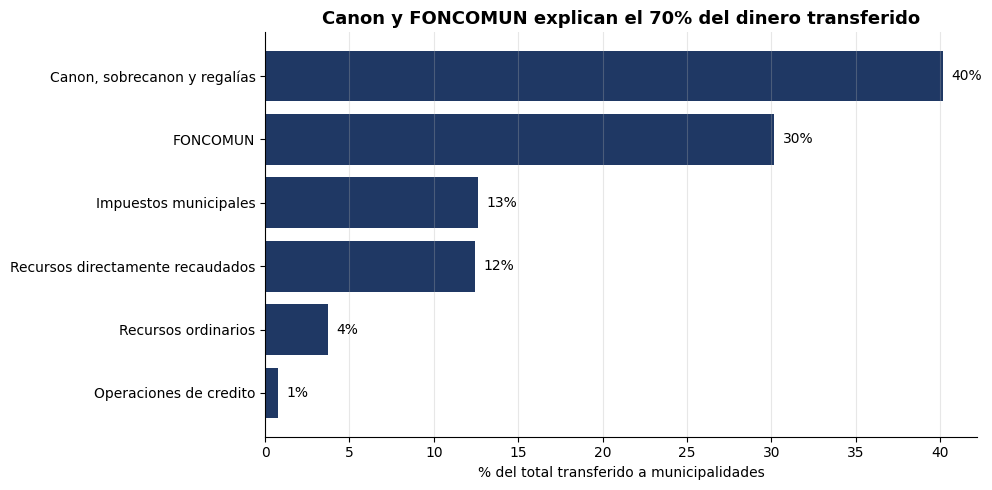

Lectura: el canon se reparte segun la produccion extractiva de cada zona, por lo que concentra recursos en pocos territorios; el FONCOMUN tiene un criterio redistributivo.


In [22]:
#GRAFICO 2: de donde viene el dinero
CORTOS = {"CANON": "Canon, sobrecanon y regalías", "COMPENSACION MUNICIPAL": "FONCOMUN",
          "IMPUESTOS MUNICIPALES": "Impuestos municipales", "DIRECTAMENTE": "Recursos directamente recaudados",
          "ORDINARIOS": "Recursos ordinarios", "CREDITO": "Operaciones de credito", "DONACIONES": "Donaciones"}
def corto(n):
    return next((v for k, v in CORTOS.items() if k in n.upper()), n.title())

r = rubros_nac / rubros_nac.sum() * 100
r = r[r >= 0.5]                                   # rubros menores a 0.5% no se muestran
fig, ax = plt.subplots(figsize=(10, 5))
etiquetas = [corto(n) for n in r.index][::-1]
barras = ax.barh(etiquetas, r.values[::-1], color=AZUL)
for b, v in zip(barras, r.values[::-1]):
    ax.text(v + 0.5, b.get_y() + b.get_height() / 2, f"{v:.0f}%", va="center", fontsize=10)
ax.set_title(f"Canon y FONCOMUN explican el {r.iloc[:2].sum():.0f}% del dinero transferido",
             fontsize=13, weight="bold")
ax.set_xlabel("% del total transferido a municipalidades")
ax.grid(axis="y", visible=False)
plt.tight_layout(); guardar(fig, "grafico_2_rubros"); plt.show()
print("Lectura: el canon se reparte segun la produccion extractiva de cada zona, por lo que concentra "
      "recursos en pocos territorios; el FONCOMUN tiene un criterio redistributivo.")

[guardado: graficos/grafico_3_top15.png]


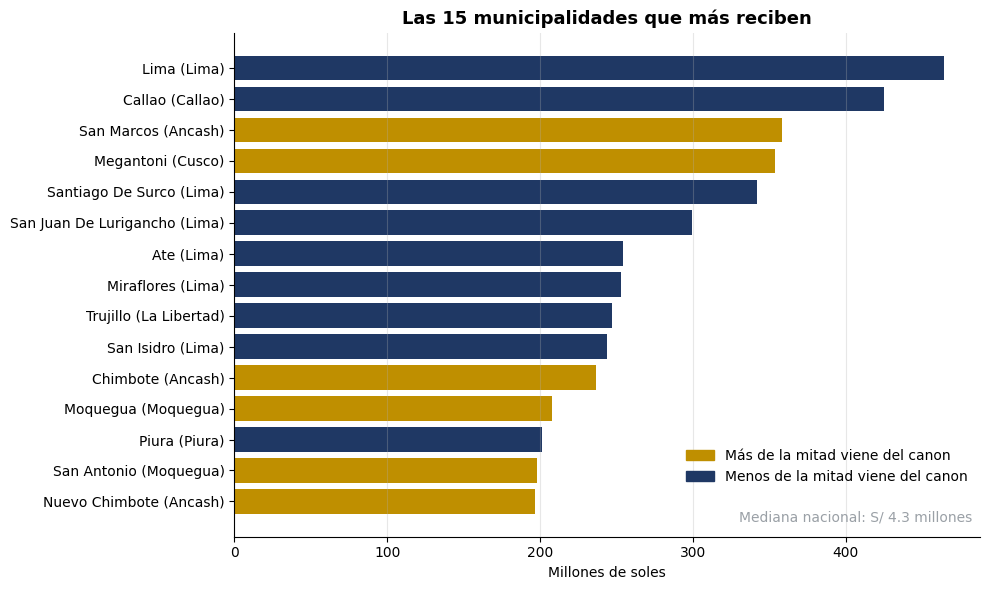

De estas 15, 6 reciben mas de la mitad de su dinero por canon.
Lectura: en el extremo superior conviven capitales muy pobladas y distritos con actividad extractiva.


In [23]:
#GRAFICO 3: las 15 municipalidades que mas reciben
top = base.nlargest(15, "MONTO_ACREDITADO").iloc[::-1]
etiq = top["distrito"].str.title() + " (" + top["departamento"].str.title() + ")"
colores = np.where(top["PCT_CANON"] >= 50, ORO, AZUL)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(etiq, top["MONTO_ACREDITADO"] / 1e6, color=colores)
ax.set_xlabel("Millones de soles")
ax.set_title("Las 15 municipalidades que más reciben", fontsize=13, weight="bold")
ax.text(0.99, 0.03, f"Mediana nacional: S/ {m.median()/1e6:.1f} millones", transform=ax.transAxes,
        ha="right", fontsize=10, color=GRIS)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=ORO, label="Más de la mitad viene del canon"),
                   Patch(color=AZUL, label="Menos de la mitad viene del canon")], loc="lower right",
          bbox_to_anchor=(1, 0.08), frameon=False)
ax.grid(axis="y", visible=False)
plt.tight_layout(); guardar(fig, "grafico_3_top15"); plt.show()
print(f"De estas 15, {int((top['PCT_CANON'] >= 50).sum())} reciben mas de la mitad de su dinero por canon.")
print("Lectura: en el extremo superior conviven capitales muy pobladas y distritos con actividad extractiva.")

## 11. Transformaciones de variables

| Transformación | Variable | Por qué |
|---|---|---|
| Logaritmo base 10 | `LOG_MONTO` | El monto abarca varios órdenes de magnitud; en log la distribución es comparable y la regla IQR tiene sentido |
| Variable derivada | `PCT_CANON`, `PCT_FONCOMUN` | Distinguen si un monto alto responde al canon (regla legal) o a otros rubros |
| Variable derivada | `ACREDITACION_PCT` | Relación entre lo acreditado y lo autorizado (Decisión 4) |
| Codificación binaria | `ES_PROVINCIAL` | `tipomuni` (1/2) pasa a 1 = provincial, 0 = distrital |
| Discretización | `DECIL_MONTO` | Grupos de 10% para leer la concentración (gráfico 1) |
| Marca de atípico | `ATIPICO` | alto / normal / bajo según IQR sobre el log (sección 9) |
| **Escalamiento: no se aplica aún** | — | La matriz se deja en unidades interpretables; se estandarizará en el siguiente hito solo si se usa un método basado en distancias (segmentación) |

In [24]:
base["ES_PROVINCIAL"] = (base[col_tipo].astype(str).str.strip() == "1").astype(int)

# MONTO_AUTORIZADO se excluye de la matriz: es practicamente igual al acreditado
print(f"Correlacion autorizado vs acreditado: {base['MONTO_AUTORIZADO'].corr(base['MONTO_ACREDITADO']):.4f}")

Correlacion autorizado vs acreditado: 1.0000


## 12. Base integrada y matriz analítica

- **Base integrada** (`salidas/base_integrada_hito2.csv`): todas las variables, incluidas las de trabajo.
- **Matriz analítica** (`salidas/matriz_analitica_hito2.csv`): 1 fila = 1 municipalidad (2024), solo las variables preparadas para el análisis siguiente.

In [25]:
base_integrada = base.drop(columns=["_merge", "UBIGEO"])
base_integrada.to_csv("salidas/base_integrada_hito2.csv", index=False, encoding="utf-8-sig")
print("Base integrada:", base_integrada.shape)

VARIABLES = {  # variable: (rol, fuente, transformacion)
    "ubigeo":           ("identificador", "RENAMU", "Texto de 6 digitos (zfill)"),
    "distrito":         ("identificador", "RENAMU", "Sin transformar"),
    "departamento":     ("descriptiva",   "RENAMU", "Sin transformar"),
    "ES_PROVINCIAL":    ("analitica",     "RENAMU", "Codificacion binaria de tipomuni"),
    "MONTO_ACREDITADO": ("analitica",     "MEF",    "Suma por distrito desde el detalle"),
    "LOG_MONTO":        ("analitica",     "Derivada", "log10 del monto acreditado"),
    "DECIL_MONTO":      ("analitica",     "Derivada", "Discretizacion en 10 grupos"),
    "PCT_CANON":        ("analitica",     "MEF",    "% del monto que viene del canon"),
    "PCT_FONCOMUN":     ("analitica",     "MEF",    "% del monto que viene del FONCOMUN"),
    "ACREDITACION_PCT": ("analitica",     "Derivada", "100 x acreditado / autorizado"),
    "ATIPICO":          ("analitica",     "Derivada", "IQR sobre LOG_MONTO"),
}
matriz = base_integrada[list(VARIABLES)].copy()
matriz.to_csv("salidas/matriz_analitica_hito2.csv", index=False, encoding="utf-8-sig")

diccionario = pd.DataFrame([{"variable": v, "rol": r, "fuente": f, "tipo": str(matriz[v].dtype),
                             "transformacion": t} for v, (r, f, t) in VARIABLES.items()])
diccionario.to_csv("salidas/diccionario_matriz_hito2.csv", index=False, encoding="utf-8-sig")

EXCLUIDAS_MATRIZ = {
    "MONTO_AUTORIZADO": "Casi identico al acreditado (redundante)",
    "MUNICIPALIDAD, DEPARTAMENTO_MEF": "Duplican la identificacion de RENAMU",
    "provincia, tipomuni": "Reemplazadas por ubigeo y ES_PROVINCIAL",
    f"{renamu.shape[1] - len(ID_RENAMU):,} columnas de RENAMU": "Fuera del alcance de este hito (se evaluaran despues)",
}
print(f"Matriz analitica: {matriz.shape[0]:,} filas x {matriz.shape[1]} variables | clave unica: {matriz['ubigeo'].is_unique}")
print("\nExcluidas de la matriz:")
for k, v in EXCLUIDAS_MATRIZ.items():
    print(f"  - {k}: {v}")
display(diccionario)
matriz.head()

Base integrada: (1891, 16)
Matriz analitica: 1,891 filas x 11 variables | clave unica: True

Excluidas de la matriz:
  - MONTO_AUTORIZADO: Casi identico al acreditado (redundante)
  - MUNICIPALIDAD, DEPARTAMENTO_MEF: Duplican la identificacion de RENAMU
  - provincia, tipomuni: Reemplazadas por ubigeo y ES_PROVINCIAL
  - 1,383 columnas de RENAMU: Fuera del alcance de este hito (se evaluaran despues)


,variable,rol,fuente,tipo,transformacion
0,ubigeo,identificador,RENAMU,object,Texto de 6 digitos (zfill)
1,distrito,identificador,RENAMU,object,Sin transformar
2,departamento,descriptiva,RENAMU,object,Sin transformar
3,ES_PROVINCIAL,analitica,RENAMU,int64,Codificacion binaria de tipomuni
4,MONTO_ACREDITADO,analitica,MEF,float64,Suma por distrito desde el detalle
5,LOG_MONTO,analitica,Derivada,float64,log10 del monto acreditado
6,DECIL_MONTO,analitica,Derivada,Int64,Discretizacion en 10 grupos
7,PCT_CANON,analitica,MEF,float64,% del monto que viene del canon
8,PCT_FONCOMUN,analitica,MEF,float64,% del monto que viene del FONCOMUN
9,ACREDITACION_PCT,analitica,Derivada,float64,100 x acreditado / autorizado


,ubigeo,distrito,departamento,ES_PROVINCIAL,MONTO_ACREDITADO,LOG_MONTO,DECIL_MONTO,PCT_CANON,PCT_FONCOMUN,ACREDITACION_PCT,ATIPICO
0,010101,CHACHAPOYAS,AMAZONAS,1,20396056.85,7.309546,9,0.869058,35.933463,99.889802,normal
1,010102,ASUNCION,AMAZONAS,0,599375.20,5.777699,1,5.687324,93.249772,100.057409,normal
2,010103,BALSAS,AMAZONAS,0,604706.50,5.781545,1,2.424484,92.365946,100.031625,normal
3,010104,CHETO,AMAZONAS,0,735704.56,5.866703,1,2.825072,75.990665,100.026077,normal
4,010105,CHILIQUIN,AMAZONAS,0,641793.06,5.807395,1,4.093647,87.161276,100.096966,normal


## 13. Conclusiones preliminares y siguiente paso

In [26]:
print(f"1. Cobertura: {CIFRAS['Municipalidades en la base']:,} municipalidades, cruce de "
      f"{100*(base['_merge']=='both').mean():.1f}% entre RENAMU y MEF.")
print(f"2. Concentracion: mediana S/ {CIFRAS['Mediana por municipalidad (S/)']:,} vs promedio "
      f"S/ {CIFRAS['Promedio por municipalidad (S/)']:,}; Gini {CIFRAS['Indice de Gini']}. "
      f"El 50% que menos recibe concentra {CIFRAS['% del total: 50% que menos recibe']}% del total y el "
      f"10% que mas recibe, {CIFRAS['% del total: 10% que mas recibe']}%.")
print(f"3. Extremos: {CIFRAS['Atipicos altos']} atipicos altos y {CIFRAS['Atipicos bajos']} bajos (IQR sobre log).")
print("4. Todo es descriptivo: no se afirma causalidad ni si el reparto es justo.")

1. Cobertura: 1,891 municipalidades, cruce de 100.0% entre RENAMU y MEF.
2. Concentracion: mediana S/ 4,340,954 vs promedio S/ 14,548,107; Gini 0.721. El 50% que menos recibe concentra 6.6% del total y el 10% que mas recibe, 61.7%.
3. Extremos: 12 atipicos altos y 0 bajos (IQR sobre log).
4. Todo es descriptivo: no se afirma causalidad ni si el reparto es justo.


**Siguiente paso:** incorporar población distrital (transferencias per cápita), estandarizar las variables de la matriz y
aplicar detección de anomalías y segmentación de municipalidades. Falta validar si los atípicos se mantienen al
controlar por población.